In [2]:
import pandas as pd 
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
folder=r'/Users/igorbykov/Desktop/Thesis/data'

# Load Commodities Data
name=r'commodities_data_v0.xlsx'
commods = pd.read_excel(
    os.path.join(folder,name),
    index_col=0
    )
commods.index = pd.to_datetime(commods.index)                   # - Ensure datatime indexation

# Load Utilities Equity Data
name=r'utilities_data_v0.xlsx'
utilities_equity=pd.read_excel(
    os.path.join(folder,name),
    index_col=0
    )
utilities_equity.index = pd.to_datetime(utilities_equity.index) # - Ensure datatime indexation

# Load Utilities Debt Data
name=r'utilities_debt.xlsx'
utilities_debt=pd.read_excel(
    os.path.join(folder,name),
    index_col=0
    )
utilities_debt.index = pd.to_datetime(utilities_debt.index)     # - Ensure datatime indexation


In [5]:
# Commodity Spot Levels
brent=commods['CO1 Comdty'] # - Brent spot; USD
ttf_ng=commods['TZT1 Comdty'] # - TTF Nat Gas Spot; USD (assumed)

# Utilities Equity Indeces (USD)
electricity_utils = utilities_equity['NDUREUTI Index'] # - Europe Electricity Utilities; USD
natgas_utils = utilities_equity['NDURGUTI Index']      # - Europe Nat Gas Utilities; USD 

# Utilities Equity Indeces (EUR)
euroxtoxx_utils = utilities_equity['SX6E Index']       # - EMU countries; EUR
stoxx600_utils = utilities_equity['SX6P Index']        # - STOXX600 European Utilities; EUR

# Utilities Debt Indeces (EUR)
# utilities_debt = utilities_debt['IGEEUA01 BVLI Index']
# utilities_debt = utilities_debt['IGEEUA03 BVLI Index']
# utilities_debt = utilities_debt['IGEEUA05 BVLI Index']
# utilities_debt = utilities_debt['IGEEUA10 BVLI Index']
# utilities_debt = utilities_debt['IGEEUA15 BVLI Index']

In [6]:
def merge_dfs(dfs:list):
    for i in range(len(dfs)):
        if i==0:
            df=dfs[i]
        else:
            df = pd.merge(df, dfs[i], left_index=True, right_index=True)
    return df

def clean_process(df):
    df=df.where(df!=0,np.nan)                               # - Replace 0 with NaNs
    df=df.dropna()                                          # - Drop NaNs (preliminarily)
    df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time axis is even
    df=df.interpolate('linear')                             # - Fill resulting NaNs with linear interpolation
    return df

In [10]:
# Aggregation
levels=clean_process(
    merge_dfs([brent, 
                  ttf_ng, 
                  electricity_utils, 
                  natgas_utils, 
                  euroxtoxx_utils, 
                  stoxx600_utils
                  ])
)


yield_curve=clean_process(
    merge_dfs([utilities_debt['IGEEUA03 BVLI Index'],
                       utilities_debt['IGEEUA05 BVLI Index'],
                       utilities_debt['IGEEUA10 BVLI Index'],
                       utilities_debt['IGEEUA15 BVLI Index']
                       ])
)

levels_and_YC=merge_dfs([levels,yield_curve])

# Returns Calculation
returns = levels_and_YC/levels_and_YC.shift(1) - 1             # - Calculate % returns
returns = returns.dropna()                                     # - Drop NaN resulting from the shift

/var/folders/4_/ym5ph8gd12lfqnhrxz6p53rw0000gn/T/ipykernel_36664/4113266116.py:12: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time axis is even
/var/folders/4_/ym5ph8gd12lfqnhrxz6p53rw0000gn/T/ipykernel_36664/4113266116.py:12: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time axis is even


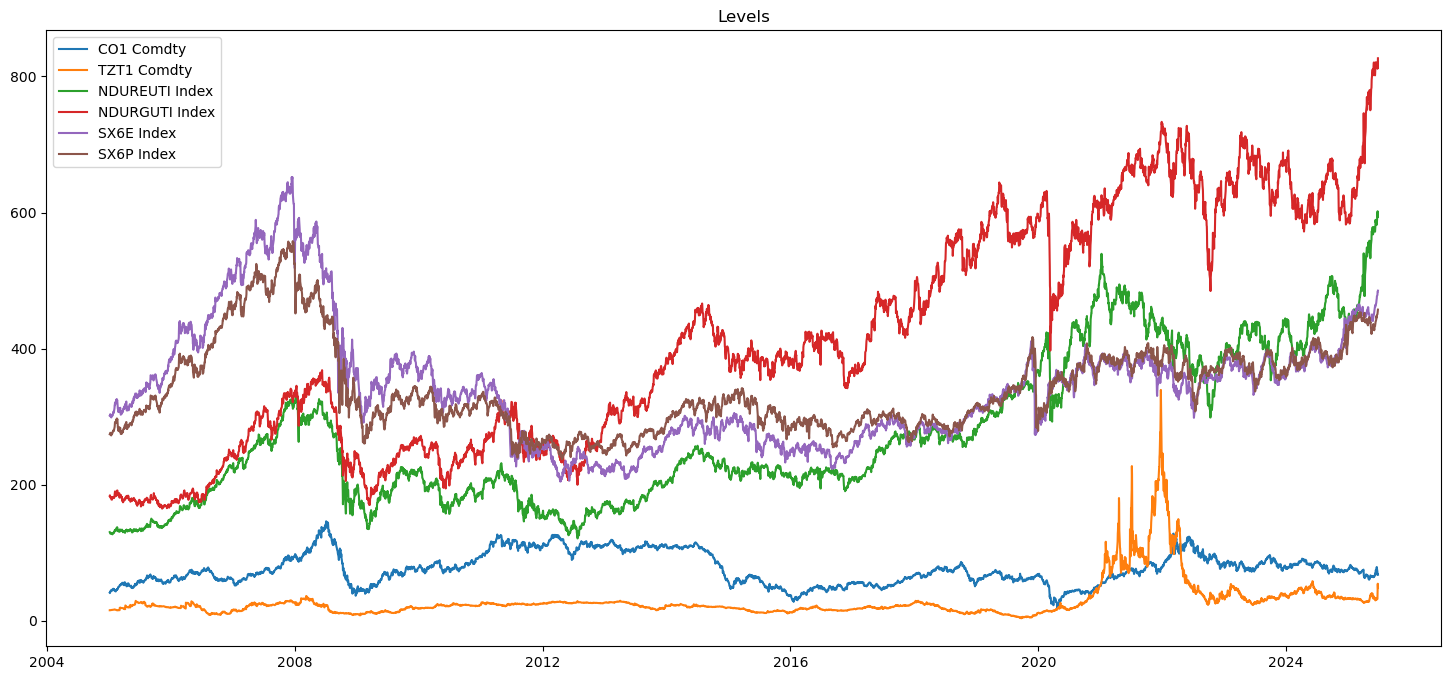

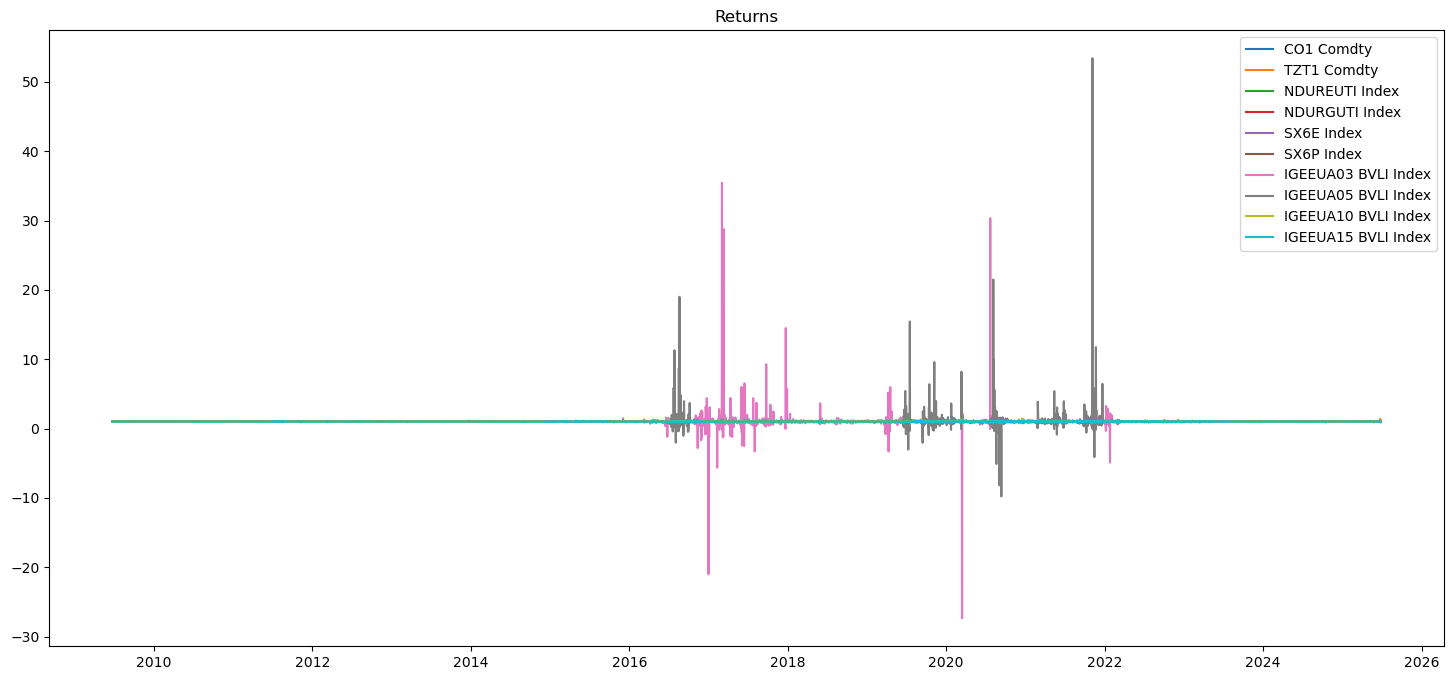

In [37]:
# Plot Levels
plt.figure(figsize=(18,8))
plt.title('Levels')
plt.plot(levels)
plt.legend(levels.columns)
plt.show()

# Plot Returns
plt.figure(figsize=(18,8))
plt.title('Returns')
plt.plot(returns)
plt.legend(returns.columns)
plt.show()

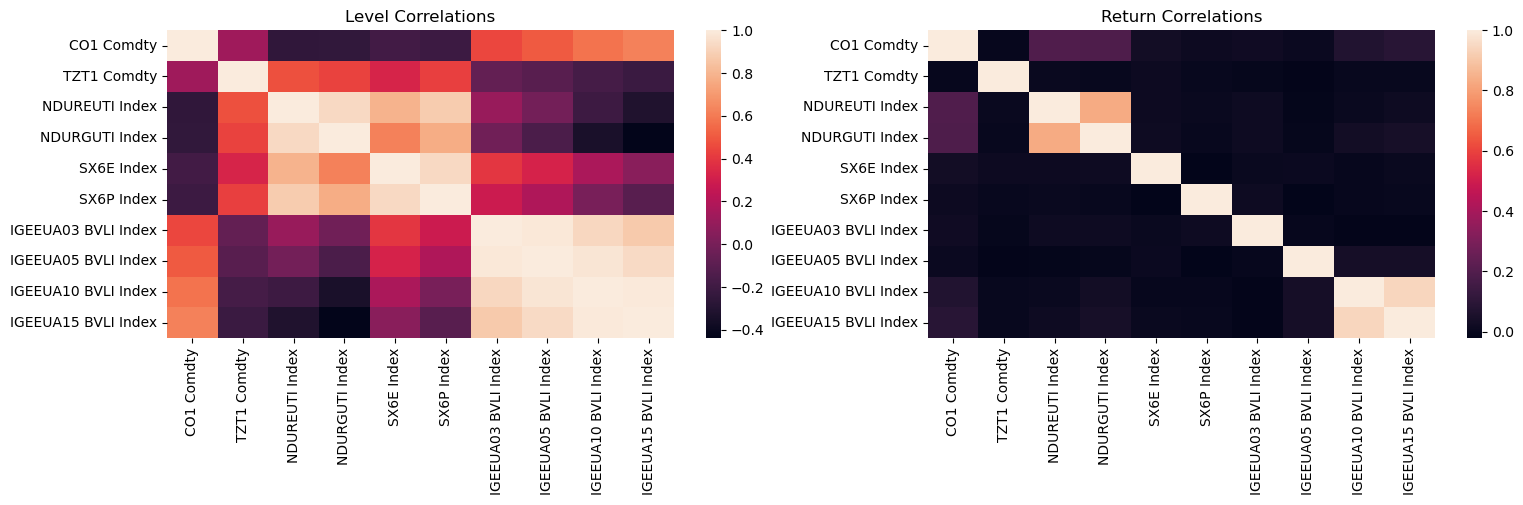

In [38]:
# Correlations Plot
plt.figure(figsize=(18,4))

# Plot Levels' Correlations
plt.subplot(1, 2, 1)
plt.title('Level Correlations')
sns.heatmap(levels_and_YC.corr())

# Plot Returns' Correlations
plt.subplot(1, 2, 2)
plt.title('Return Correlations')
sns.heatmap(returns.corr())

plt.show()

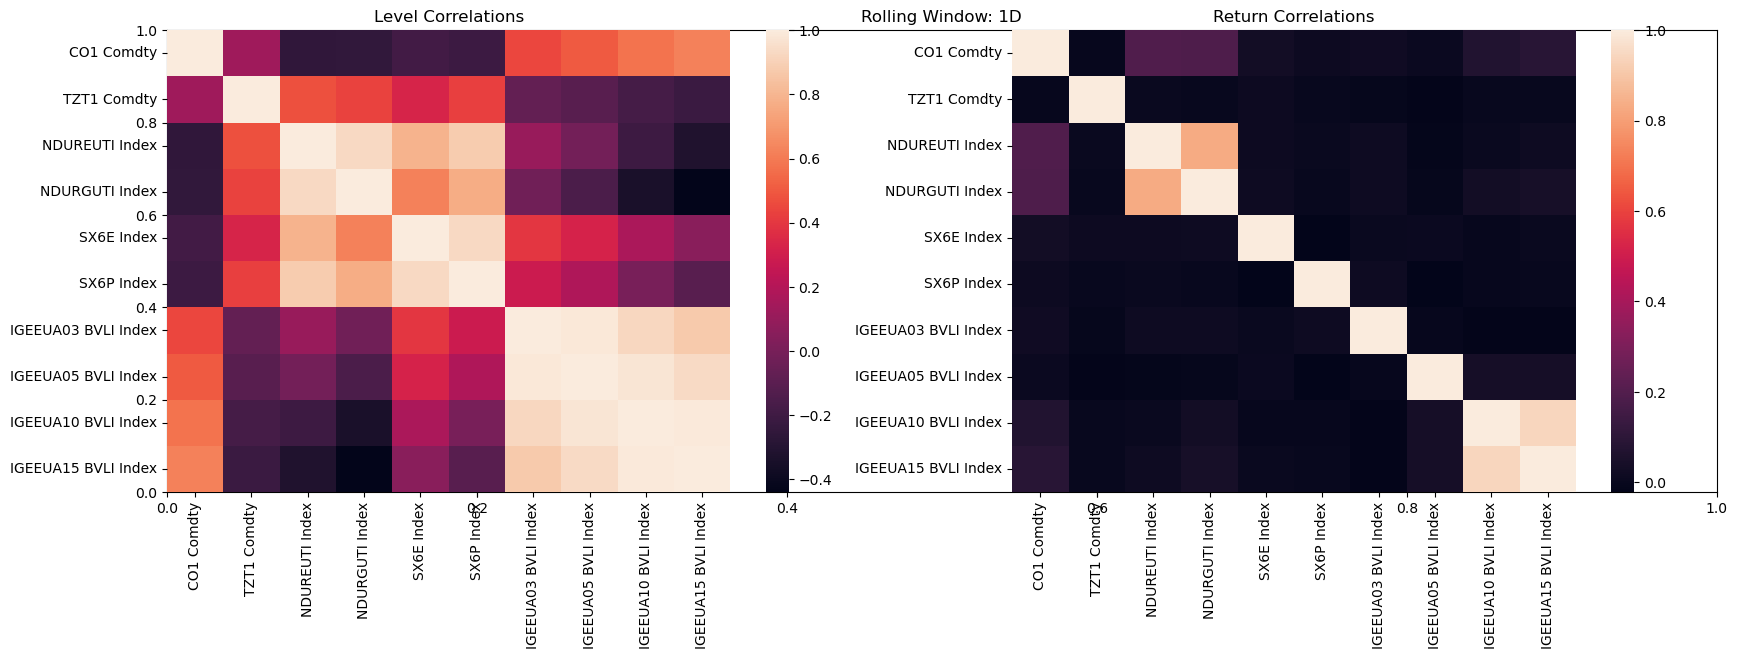

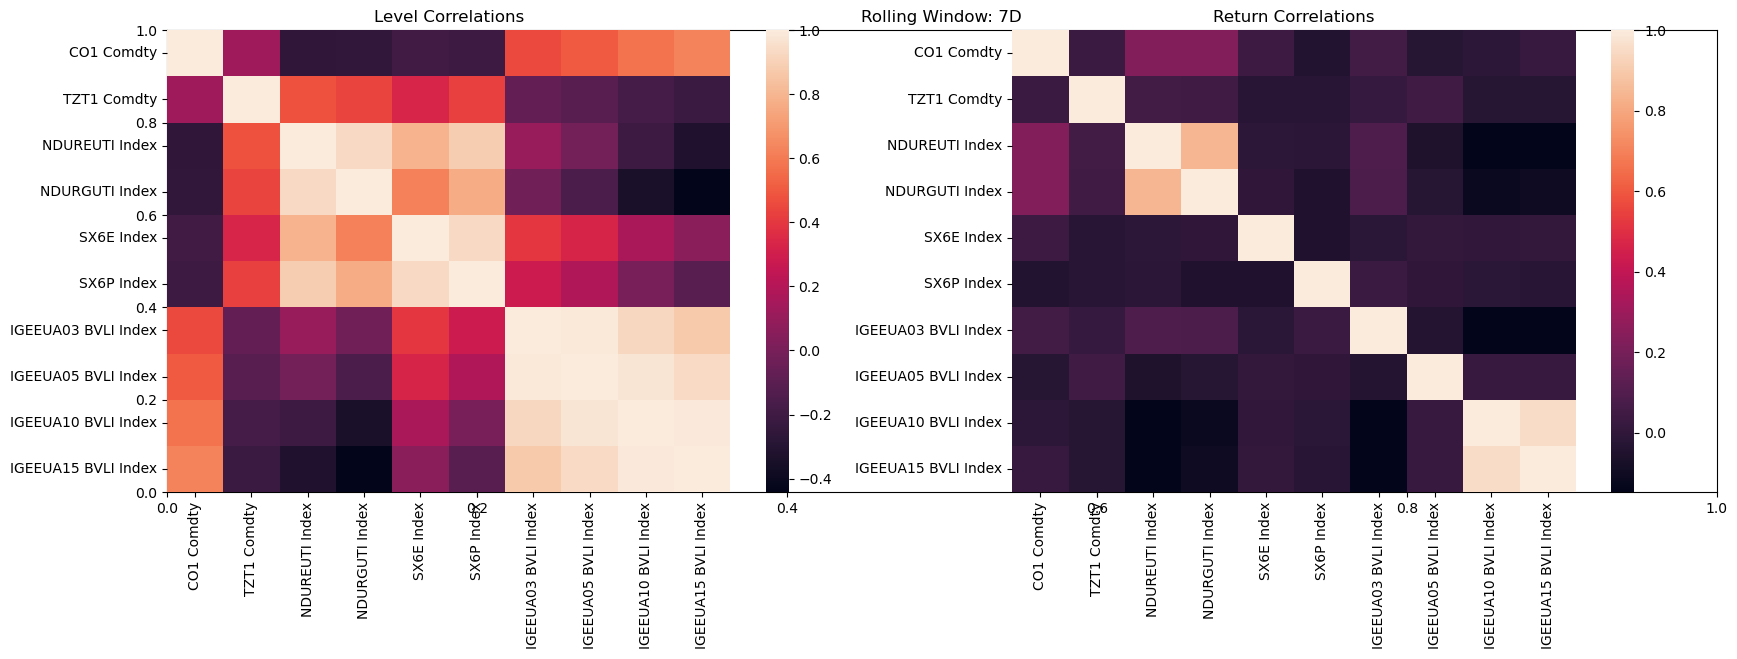

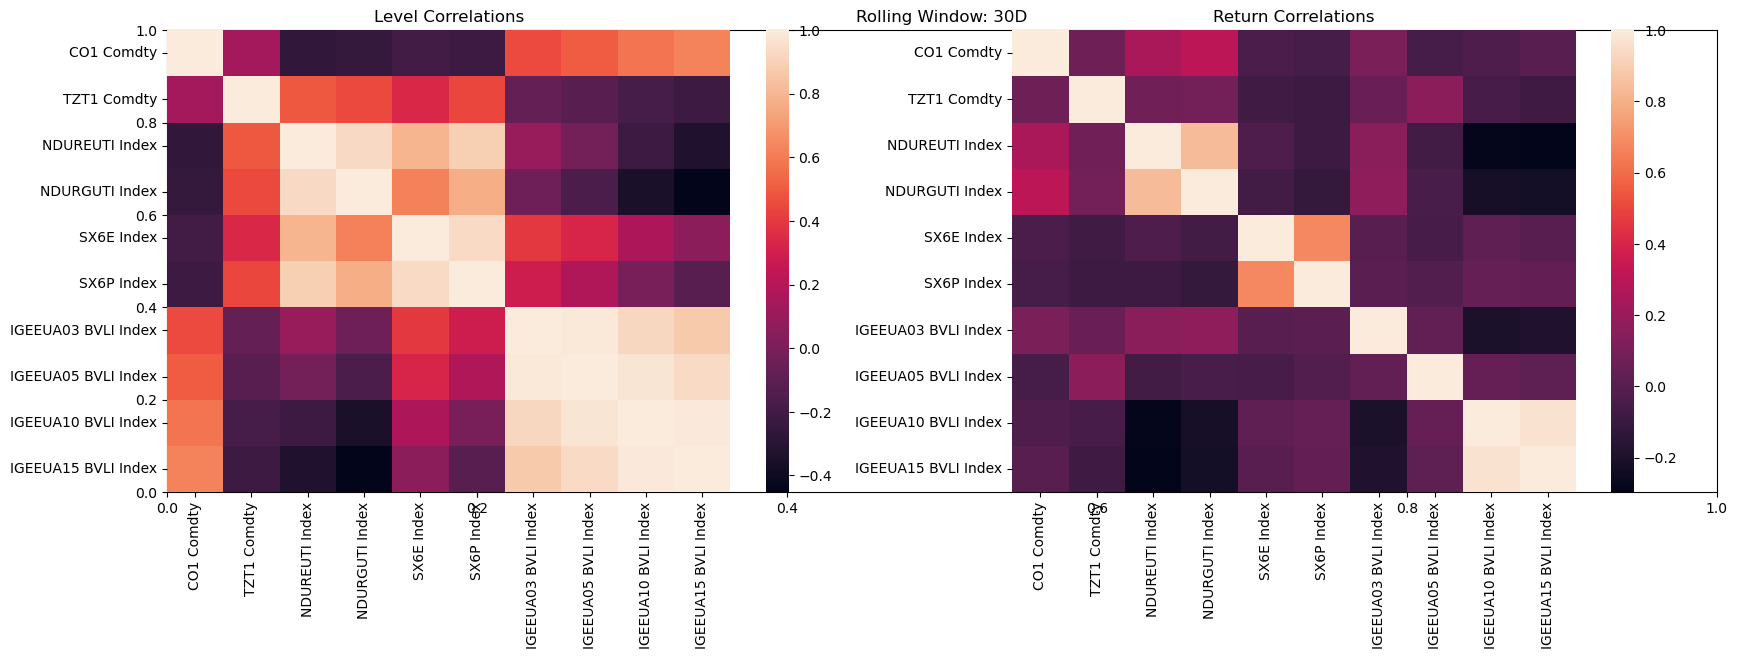

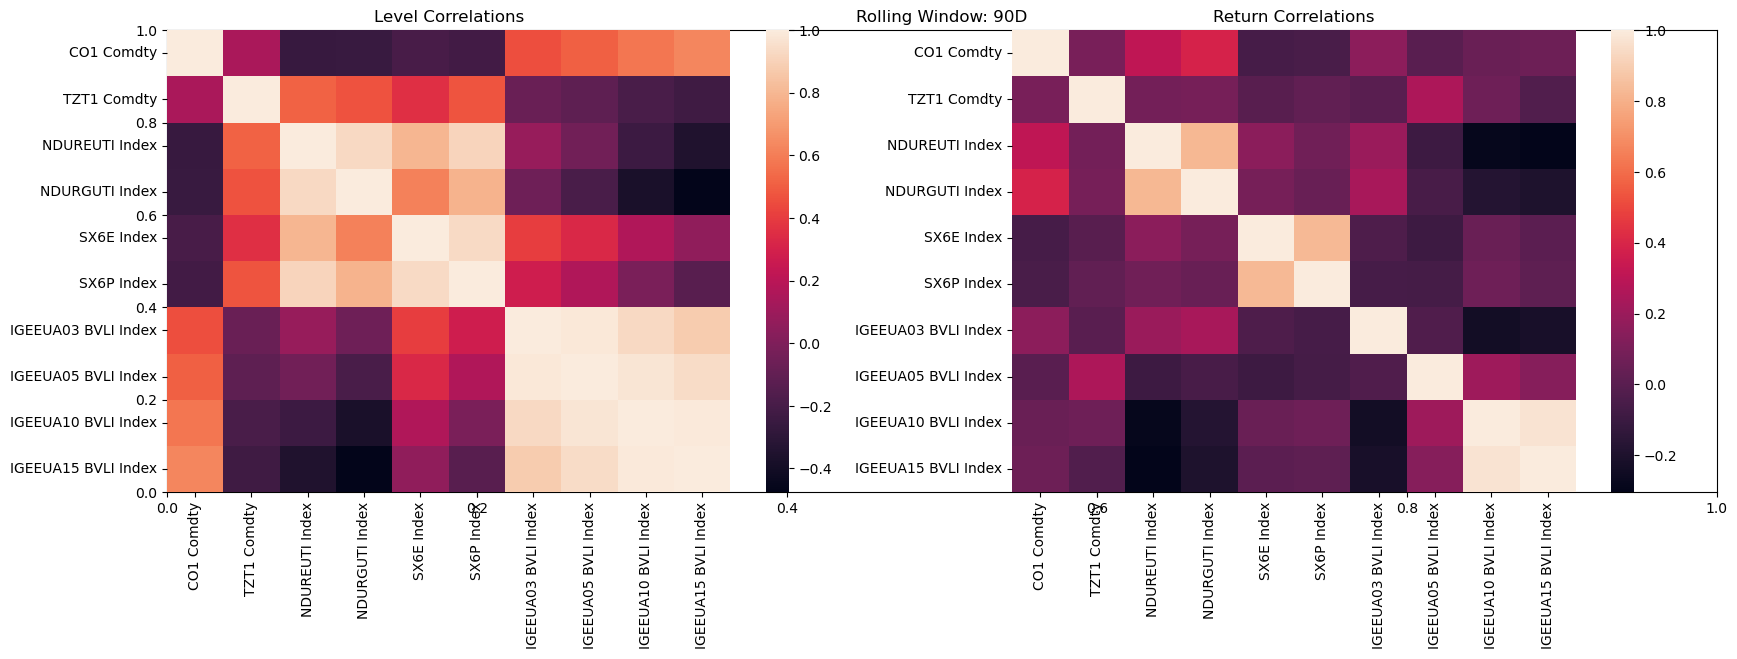

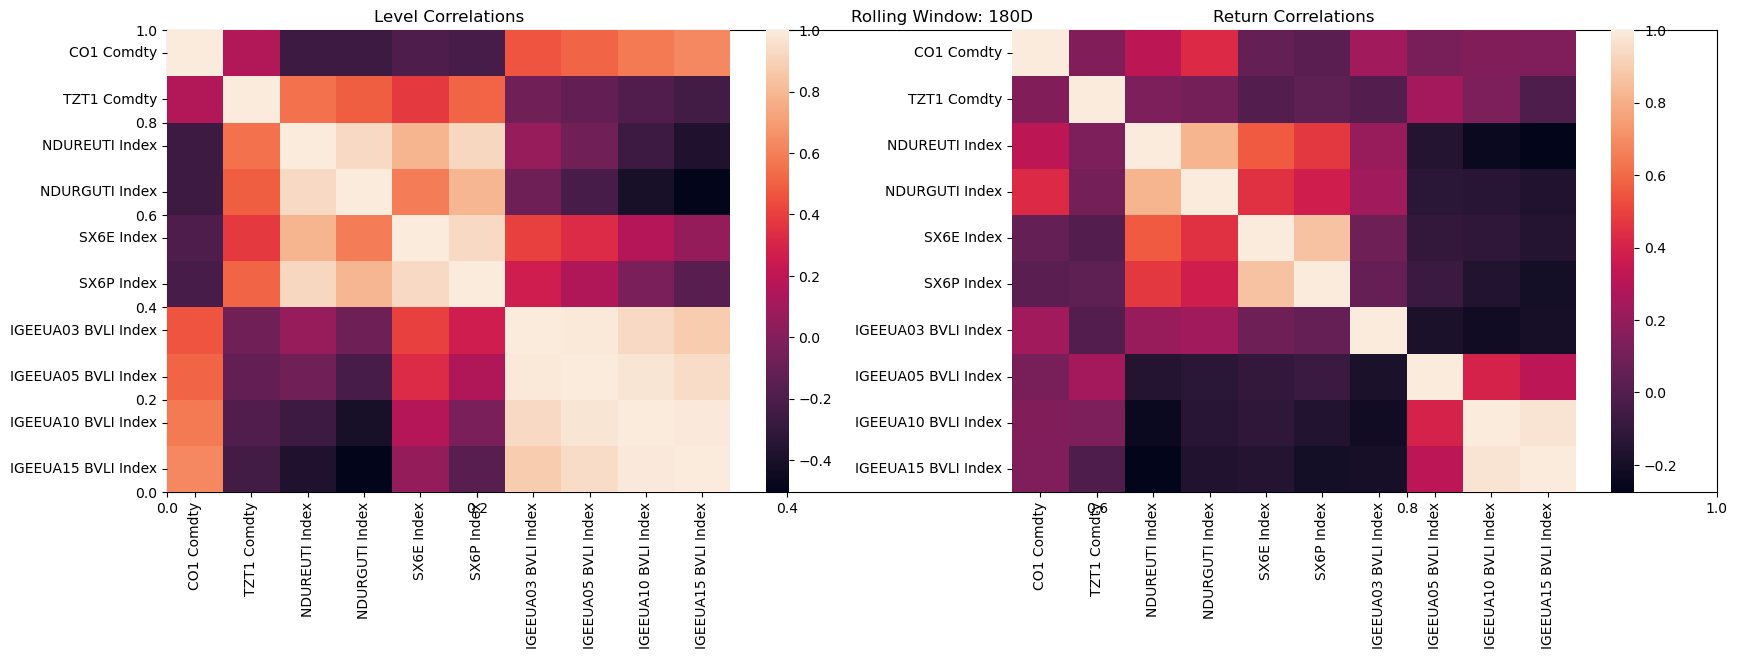

In [44]:
# Consider different timeseries forms:
#   End:        Month, Quarter, Half
#   Rolling:    Month, Quarter, Half

steps = ["1D" ,"7D", "30D", "90D", "180D"]

for s in steps:

    # Correlations Plot
    plt.figure(figsize=(20,6))

    plt.title(f'Rolling Window: {s}')

    # Plot Levels' Correlations
    plt.subplot(1, 2, 1)
    plt.title('Level Correlations')
    sns.heatmap(levels_and_YC.rolling(s).mean().corr())

    # Plot Returns' Correlations
    plt.subplot(1, 2, 2)
    plt.title('Return Correlations')
    sns.heatmap(returns.rolling(s).mean().corr())

    plt.show()

In [ ]:
return

,CO1 Comdty,TZT1 Comdty,NDUREUTI Index,NDURGUTI Index,SX6E Index,SX6P Index,IGEEUA03 BVLI Index,IGEEUA05 BVLI Index,IGEEUA10 BVLI Index,IGEEUA15 BVLI Index
2009-06-22,66.980000,13.537000,182.002000,213.651000,345.310000,298.590000,3.1206,3.9118,4.7989,5.2329
2009-06-23,68.800000,13.575000,185.334000,217.965000,348.440000,299.930000,3.1472,3.9183,4.8089,5.2293
2009-06-24,68.330000,13.747000,189.516000,221.631000,356.660000,301.700000,3.1009,3.8811,4.7869,5.1902
2009-06-25,69.780000,13.992000,187.206000,220.446000,353.720000,304.750000,3.0392,3.8284,4.7475,5.1376
2009-06-26,68.920000,14.000000,187.058000,224.217000,356.780000,302.410000,3.0620,3.8258,4.7140,5.0906
...,...,...,...,...,...,...,...,...,...,...
2025-06-22,73.323333,32.047333,592.763667,812.103333,478.243333,450.076667,2.5295,2.8631,3.4136,3.7347
2025-06-23,71.480000,31.959000,595.326000,811.377000,478.860000,450.460000,2.5262,2.8583,3.4093,3.7296
2025-06-24,67.140000,44.506000,601.889000,821.648000,483.620000,452.840000,2.5165,2.8552,3.4198,3.7426
2025-06-25,67.680000,54.290000,593.172000,812.594000,483.640000,455.540000,2.5238,2.8720,3.4488,3.7808


In [ ]:
# Assume 5-yr duration
D_5 = -4.5

